In [1]:
import numpy as np
import time
from scipy import misc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(style='normal', size=20)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_dtype(torch.float64)
import random
import math
import pandas as pd
from scipy.optimize import fsolve
# from scipy.integrate import solve_ivp # type: ignore
import scipy.integrate as integrate

import json

from IPython.display import display, Math, Markdown
import seaborn as sns
sns.set(font_scale = 2)

import pandas as pd
import datetime
import os
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
timestamp
version = '_7'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_56779/3081477246.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


Using 21 runs


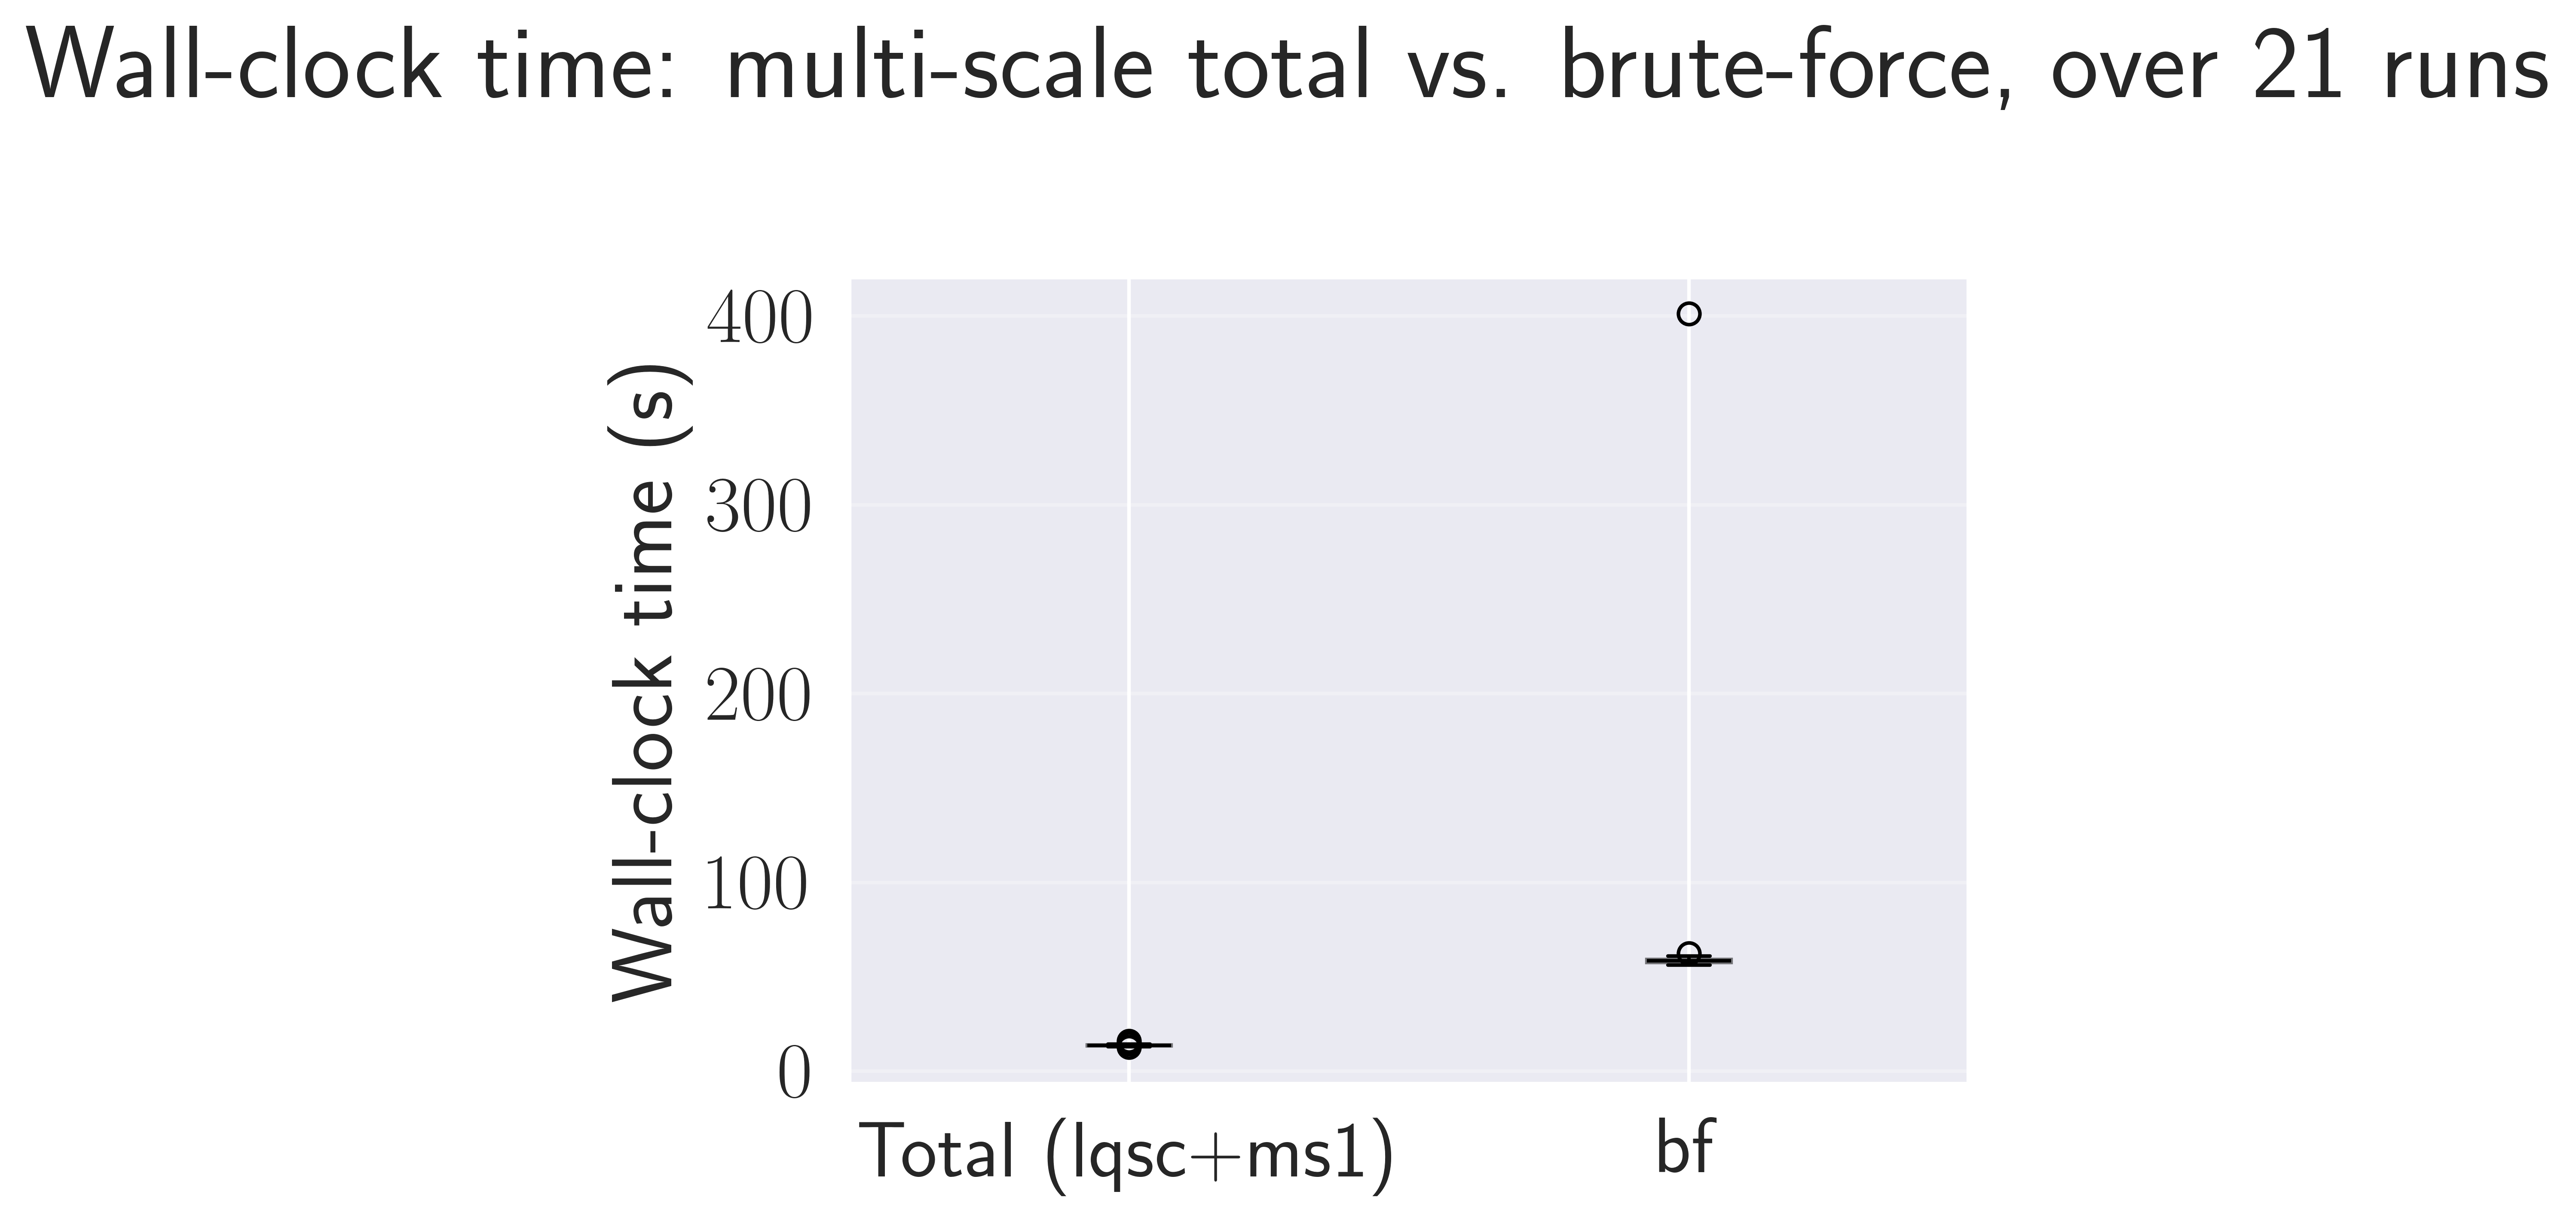

In [2]:
# Boxplot: Total (lqsc+ms1) vs bf, over all logged runs
import json as _json

with open('wallclock_log.json') as f:
    wallclock_log = _json.load(f)

runs = wallclock_log['runs']
print(f"Using {len(runs)} runs")

total_vals = [r['lqsc_policy_s'] + r['lqsc_value_s'] + r['lqsc_value_retrain_s'] + r['ms1_policy_s'] for r in runs]
bf_vals = [r['bf_train_s'] for r in runs]

fig, ax = plt.subplots(figsize=(6, 5), dpi=600)

box_color = 'steelblue'
boxprops = dict(facecolor=box_color, alpha=0.5, edgecolor='black')
medianprops = dict(color='black')
whiskerprops = dict(color='black')
capprops = dict(color='black')

ax.boxplot([total_vals, bf_vals], patch_artist=True,
           boxprops=boxprops, medianprops=medianprops,
           whiskerprops=whiskerprops, capprops=capprops,
           tick_labels=['Total (lqsc+ms1)', 'bf'])
ax.set_ylabel('Wall-clock time (s)')
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Wall-clock time: multi-scale total vs. brute-force, over {len(runs)} runs')
plt.tight_layout()
plt.savefig('lqc_wallclock_boxplot.png', dpi=600, bbox_inches='tight')
plt.show()